In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("Online Retail.xlsx")

print("Dataset loaded:", df.shape)

Dataset loaded: (541909, 8)


In [2]:
df = df.drop_duplicates()

df = df[df["Quantity"] > 0]

df = df[df["UnitPrice"] > 0]

df = df.dropna(subset=["CustomerID"])

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

print("Cleaned data:", df.shape)

Cleaned data: (392692, 9)


In [3]:
cutoff_date = pd.Timestamp("2011-09-01")

historical_data = df[df["InvoiceDate"] < cutoff_date].copy()

future_data = df[df["InvoiceDate"] >= cutoff_date].copy()

print("Historical transactions:", historical_data.shape)
print("Future transactions:", future_data.shape)

Historical transactions: (224036, 9)
Future transactions: (168656, 9)


In [4]:
customer_data = historical_data.groupby("CustomerID").agg({
    "InvoiceDate": ["min", "max"],
    "InvoiceNo": "nunique",
    "Quantity": "sum",
    "TotalAmount": "sum"
})

customer_data.columns = [
    "FirstPurchase",
    "LastPurchase",
    "Frequency",
    "TotalItems",
    "HistoricalMonetary"
]

customer_data["Recency"] = (
    cutoff_date - customer_data["LastPurchase"]
).dt.days

customer_data["AverageOrderValue"] = (
    customer_data["HistoricalMonetary"] /
    customer_data["Frequency"]
)

customer_data["Tenure"] = (
    cutoff_date - customer_data["FirstPurchase"]
).dt.days

In [5]:
future_spending = future_data.groupby("CustomerID")["TotalAmount"].sum()

customer_data["FutureLTV"] = (
    future_spending.reindex(customer_data.index)
    .fillna(0)
)

In [6]:
customer_data.head()

,FirstPurchase,LastPurchase,Frequency,TotalItems,HistoricalMonetary,Recency,AverageOrderValue,Tenure,FutureLTV
CustomerID,,,,,,,,,
12346.0,2011-01-18 10:01:00,2011-01-18 10:01:00,1,74215,77183.60,225,77183.600000,225,0.00
12347.0,2010-12-07 14:57:00,2011-08-02 08:48:00,5,1590,2790.86,29,558.172000,267,1519.14
12348.0,2010-12-16 19:09:00,2011-04-05 10:47:00,3,2124,1487.24,148,495.746667,258,310.00
12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,1,197,334.40,210,334.400000,210,0.00
12352.0,2011-02-16 12:33:00,2011-03-22 16:08:00,5,254,1561.81,162,312.362000,196,944.23


In [7]:
customer_data.shape

(3317, 9)

In [8]:
customer_data[[
    "Recency",
    "Frequency",
    "HistoricalMonetary",
    "FutureLTV"
]].describe()

,Recency,Frequency,HistoricalMonetary,FutureLTV
count,3317.000000,3317.000000,3317.000000,3317.000000
mean,92.142900,3.440760,1575.966292,911.682539
std,76.687522,5.586463,5974.011671,5185.916163
min,0.000000,1.000000,2.900000,0.000000
25%,27.000000,1.000000,258.250000,0.000000
50%,72.000000,2.000000,552.800000,200.390000
75%,146.000000,4.000000,1355.110000,747.100000
max,273.000000,127.000000,176355.940000,168469.600000


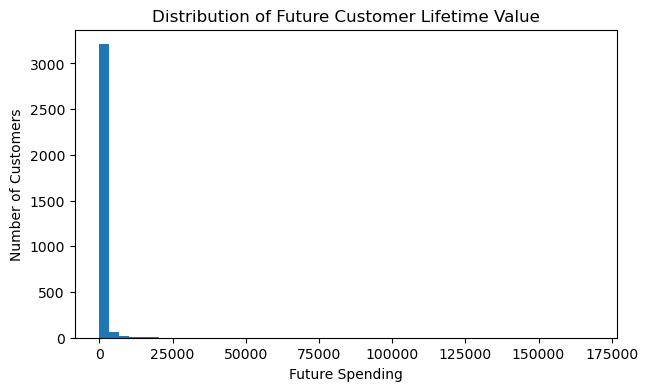

In [9]:
plt.figure(figsize=(7,4))

plt.hist(customer_data["FutureLTV"], bins=50)

plt.title("Distribution of Future Customer Lifetime Value")
plt.xlabel("Future Spending")
plt.ylabel("Number of Customers")

plt.show()

In [10]:
features = [
    "Recency",
    "Frequency",
    "HistoricalMonetary",
    "AverageOrderValue",
    "TotalItems",
    "Tenure"
]

X = customer_data[features]

y = customer_data["FutureLTV"]

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (2653, 6)
Testing: (664, 6)


In [12]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
y_pred = model.predict(X_test)

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(y_test, y_pred) ** 0.5

r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²   :", round(r2, 4))

MAE : 991.49
RMSE: 5101.22
R²   : 0.4338


In [15]:
import joblib

joblib.dump(model, "ltv_model.pkl")

print("LTV model saved successfully!")

LTV model saved successfully!
